### **Alur DBSCAN Manhattan**

Load Data → Pilih Teks → Preprocessing → TF-IDF → Tentukan eps → DBSCAN → Evaluasi → Visualisasi

**Load Data**

In [1]:
import pandas as pd

# load data
df = pd.read_csv('komdigi_hoaks.csv')

# lihat 5 baris pertama
df.head()

,id,url,title,slug,published_at,view_count,excerpt,body_html,body_text,main_image_url,category,tags,topics
0,65399,https://www.komdigi.go.id/berita/berita-hoaks/...,[HOAKS] Tautan Pencairan BSU September 2026 Se...,hoaks-tautan-pencairan-bsu-september-2026-sebe...,2026-09-27 23:03:00,272,Kepala Biro Humas Kementerian Ketenagakerjaan ...,"<p style=""margin-left:0in;text-align:justify;""...",Penjelasan: Beredar sebuah unggahan berisi tau...,https://web.komdigi.go.id/resource/dXBsb2Fkcy8...,Klarifikasi Hoaks,hoaks hari ini,Hoaks
1,65398,https://www.komdigi.go.id/berita/berita-hoaks/...,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...,hoaks-panas-el-nino-berkaitan-dengan-gelombang...,2026-09-27 23:02:00,156,El Nino merupakan fenomena alam yang terjadi a...,"<p style=""margin-left:0in;text-align:justify;""...",Penjelasan: Beredar unggahan di media sosial I...,https://web.komdigi.go.id/resource/dXBsb2Fkcy8...,Klarifikasi Hoaks,hoaks hari ini,Hoaks
2,65397,https://www.komdigi.go.id/berita/berita-hoaks/...,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...,hoaks-susu-bebelac-berbahaya-karena-mengandung...,2026-09-27 23:01:00,146,Maltodekstrin merupakan bahan tambahan pangan ...,"<p style=""margin-left:0in;text-align:justify;""...",Penjelasan: Beredar unggahan di media sosial T...,https://web.komdigi.go.id/resource/dXBsb2Fkcy8...,Klarifikasi Hoaks,hoaks hari ini,Hoaks
3,65392,https://www.komdigi.go.id/berita/berita-hoaks/...,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...,hoaks-purbaya-informasikan-raffi-ahmad-beli-ko...,2026-09-26 23:04:00,224,NaN,<p>Penjelasan: &nbsp;</p><p>Beredar sebuah ung...,Penjelasan: Beredar sebuah unggahan video di m...,https://web.komdigi.go.id/resource/dXBsb2Fkcy8...,Klarifikasi Hoaks,hoaks hari ini,Hoaks
4,65391,https://www.komdigi.go.id/berita/berita-hoaks/...,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...,hoaks-tautan-bantuan-laptop-dan-ponsel-untuk-m...,2026-09-26 23:02:00,309,NaN,<p>Penjelasan: &nbsp;</p><p>Beredar unggahan d...,Penjelasan: Beredar unggahan di media sosial F...,https://web.komdigi.go.id/resource/dXBsb2Fkcy8...,Klarifikasi Hoaks,hoaks hari ini,Hoaks


**Pilih Kolom Teks & Preprocessing**

In [5]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)          # hapus URL
    text = re.sub(r'[^a-z\s]', ' ', text)        # hapus angka & tanda baca
    text = re.sub(r'\s+', ' ', text).strip()     # rapikan spasi
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# pakai kolom title + excerpt (ringkasan berita, lebih ringkas dari body_text)
df['text_clean'] = (df['title'].fillna('') + ' ' + df['excerpt'].fillna('')).apply(clean_text)

df[['title', 'text_clean']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alexsa\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,title,text_clean
0,[HOAKS] Tautan Pencairan BSU September 2026 Se...,hoaks tautan pencairan bsu september kepala bi...
1,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...,hoaks panas nino berkaitan gelombang frekuensi...
2,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...,hoaks susu bebelac berbahaya mengandung maltod...
3,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...,hoaks purbaya informasikan raffi ahmad beli ko...
4,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...,hoaks tautan bantuan laptop ponsel mahasiswa


**TF-IDF**

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# max_features=1000 hanya ambil 1000 kata paling penting
# min_df=5 → kata harus muncul minimal di 5 dokumen
# max_df=0.8 → buang kata yang muncul di >80% dokumen (terlalu umum)
tfidf = TfidfVectorizer(max_features=1000, min_df=5, max_df=0.8)
X = tfidf.fit_transform(df['text_clean'])

print("Shape TF-IDF:", X.shape)

Shape TF-IDF: (4176, 1000)


**Tentukan eps**

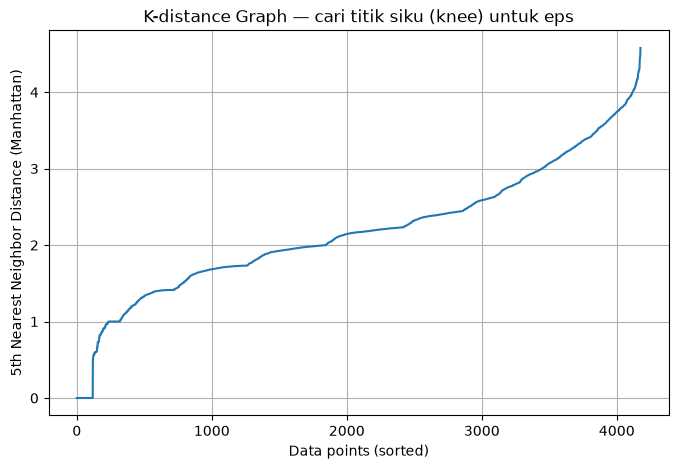

In [9]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

X_dense = X.toarray()   # ubah ke dense array

# hitung jarak ke 5 tetangga terdekat (manhattan)
nbrs = NearestNeighbors(n_neighbors=5, metric='manhattan').fit(X_dense)
distances, _ = nbrs.kneighbors(X_dense)

# urutkan jarak ke tetangga ke-5
k_dist = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(k_dist)
plt.xlabel('Data points (sorted)')
plt.ylabel('5th Nearest Neighbor Distance (Manhattan)')
plt.title('K-distance Graph — cari titik siku (knee) untuk eps')
plt.grid(True)
plt.show()

**Jalankan DBSCAN Manhattan**

In [10]:
from sklearn.cluster import DBSCAN

# ganti eps sesuai hasil k-distance graph kamu
dbscan = DBSCAN(eps=0.9, min_samples=5, metric='manhattan')
labels = dbscan.fit_predict(X_dense)

df['cluster'] = labels

# lihat hasil
print(df['cluster'].value_counts().sort_index())
print(f"\nJumlah cluster: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Jumlah noise: {list(labels).count(-1)}")

cluster
-1     3946
 0        7
 1       44
 2       20
 3        7
 4        8
 5        9
 6       13
 7        5
 8        8
 9        5
 10      14
 11       9
 12       5
 13       6
 14       6
 15      13
 16      14
 17       5
 18       5
 19       8
 20       5
 21       5
 22       9
Name: count, dtype: int64

Jumlah cluster: 23
Jumlah noise: 3946


**Evaluasi**

In [11]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

mask = labels != -1   # buang noise

if len(set(labels[mask])) > 1:
    sil = silhouette_score(X_dense[mask], labels[mask], metric='manhattan')
    dbi = davies_bouldin_score(X_dense[mask], labels[mask])
    print(f"Silhouette Score : {sil:.4f}")
    print(f"Davies-Bouldin   : {dbi:.4f}")
    print(f"Jumlah cluster   : {len(set(labels[mask]))}")
    print(f"Jumlah noise     : {list(labels).count(-1)}")
else:
    print("Cluster cuma 1 atau semua noise — tuning eps dulu")

Silhouette Score : 0.6736
Davies-Bouldin   : 0.5881
Jumlah cluster   : 23
Jumlah noise     : 3946


**Visualisasi**

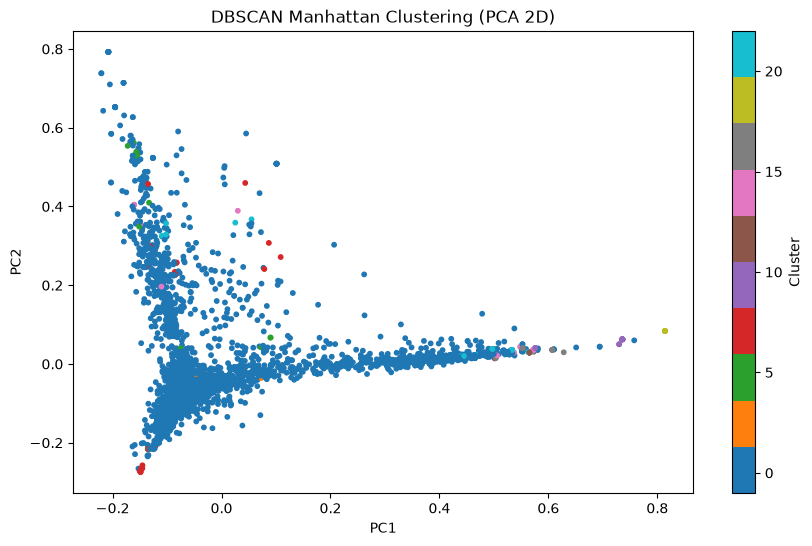

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=10)
plt.title('DBSCAN Manhattan Clustering (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.show()

**Analisis**

In [17]:
hasil = evaluasi_dbscan(X_dense, eps=0.9, min_samples=5, metric='manhattan')

# hanya tampilkan 5 field yang diinginkan
kolom_pilihan = ['metode', 'cluster', 'silhouette', 'waktu (s)', 'memory (MB)']

for key in kolom_pilihan:
    if key in hasil:
        print(f"{key:20s}: {hasil[key]}")

metode              : DBSCAN-manhattan
cluster             : 23
silhouette          : 0.6736
waktu (s)           : 13.2748
memory (MB)         : 3.9
